In [1]:
from funkcje.Lorentz2Raman import *

In [2]:
#import wszystkich mapek (i pojedynczych widm dla t=8s) dla próbki 1
BASE = Path().resolve()
sciezka = BASE / "analiza" / "próbka3" / "dane_pomiarowe"

rs_PL_0s, I_PL_0s = importMap(sciezka/"WSe2_mapa_PL_3_0s.txt")
rs_PL_2min, I_PL_2min = importSpectrum(sciezka/"WSe2_mapa_PL_3_2min.txt")


rs_Raman_0s, I_Raman_0s = importMap(sciezka/"WSe2_mapa_Raman_3_0s.txt")
rs_Raman_2min, I_Raman_2min = importMap(sciezka/"WSe2_mapa_Raman_3_2min.txt")



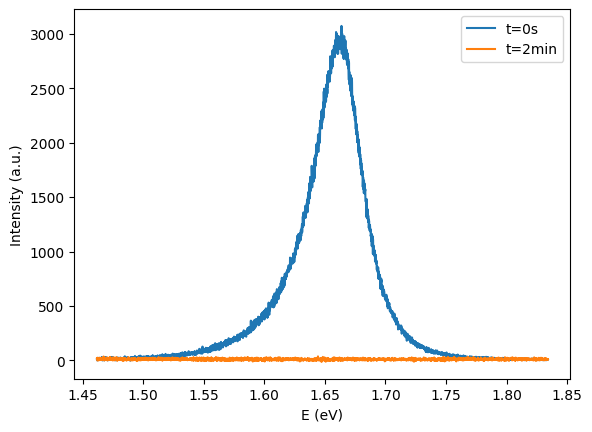

In [3]:
#testowe pojedyncze widma PL, żebym wiedziała co dopasować 
plt.plot(rs_PL_0s[123], I_PL_0s[123],label="t=0s")
plt.plot(rs_PL_2min, I_PL_2min,label="t=2min")
plt.xlabel(r"E (eV)")
plt.ylabel("Intensity (a.u.)")
plt.legend()

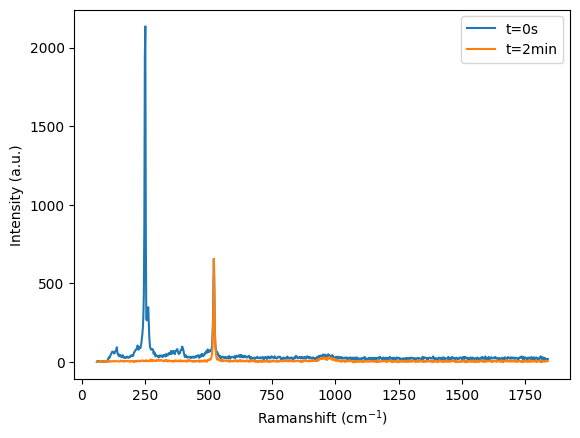

In [4]:
# testowe pojedyncze widma ramana, żebym wiedziała co dopasować 
plt.plot(rs_Raman_0s[123], I_Raman_0s[123],label="t=0s")
plt.plot(rs_Raman_2min[123], I_Raman_2min[123],label="t=2min")
plt.xlabel(r"Ramanshift (cm$^{-1}$)")
plt.ylabel("Intensity (a.u.)")
plt.legend()
#plt.xlim(200,300)

In [5]:
#dopasowanie PL
centers_PL_0s, fwhms_PL_0s, intensities_PL_0s = lorentz2map(rs_PL_0s, I_PL_0s, xmin=1.5, xmax=1.7)




In [6]:
#dopasowanie E
centers_Raman_E_0s, fwhms_Raman_E_0s, intensities_Raman_E_0s = lorentz2map(rs_Raman_0s, I_Raman_0s, xmin=240, xmax=255)



In [7]:
#dopasowanie A
centers_Raman_A_0s, fwhms_Raman_A_0s, intensities_Raman_A_0s = lorentz2map(rs_Raman_0s, I_Raman_0s, xmin=255, xmax=265)


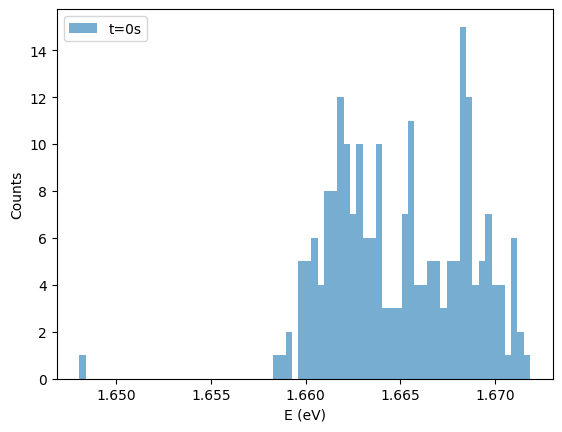

In [8]:
#histogramy pozycji piku PL
plt.hist(centers_PL_0s, bins=70, label="t=0s", alpha=0.6)

plt.xlabel(r"E (eV)")
plt.ylabel("Counts")
plt.legend()


BASE = Path().resolve()
sciezka = BASE / "analiza" / "próbka3" / "wykresy"
plt.savefig(sciezka/'histogram_pozycji_PL.png')

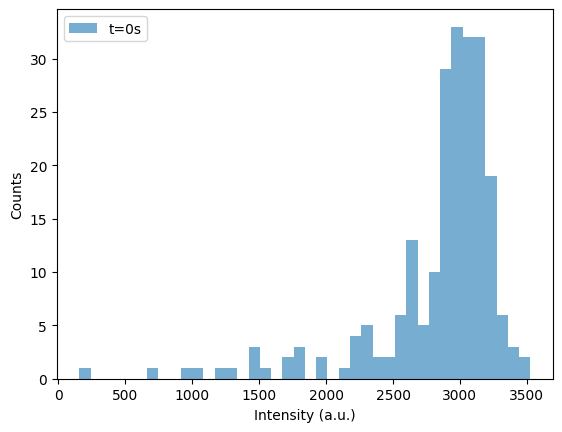

In [9]:
#histogramy intensywności piku PL
plt.hist(intensities_PL_0s, bins=40, label="t=0s", alpha=0.6)

plt.xlabel(r"Intensity (a.u.)")
plt.ylabel("Counts")
plt.legend()
plt.savefig(sciezka/'histogram_intensywnosci_PL.png')

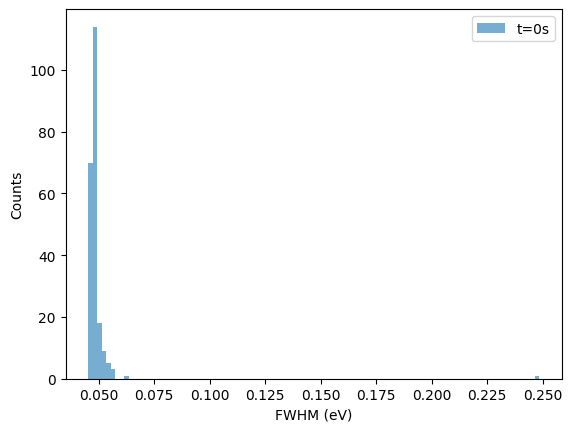

In [13]:
#histogramy fwhm piku PL
plt.hist(fwhms_PL_0s, bins=100, label="t=0s", alpha=0.6)

plt.xlabel(r"FWHM (eV)")
plt.ylabel("Counts")
plt.legend()
plt.savefig(sciezka/'histogram_fwhm_PL.png')

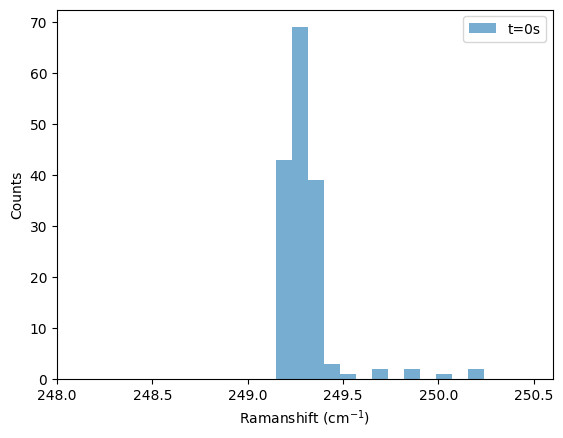

In [16]:
#histogramy pozycji piku Raman E
plt.hist(centers_Raman_E_0s, bins=70, label="t=0s", alpha=0.6)

plt.xlabel(r"Ramanshift (cm$^{-1}$)")
plt.ylabel("Counts")
plt.legend()
plt.xlim(248,250.6)
plt.savefig(sciezka/'histogram_pozycji_Raman_E.png')

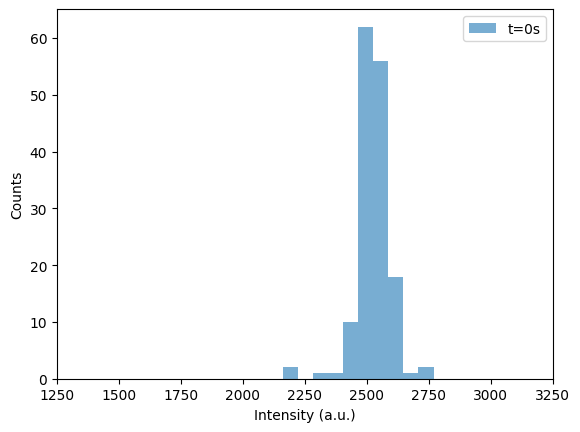

In [15]:
#histogramy intensywności Raman E
plt.hist(intensities_Raman_E_0s, bins=80, label="t=0s", alpha=0.6)

plt.xlabel(r"Intensity (a.u.)")
plt.ylabel("Counts")
plt.legend()
plt.xlim(1250,3250)
plt.savefig(sciezka/'histogram_intensywnosci_Raman_E.png')

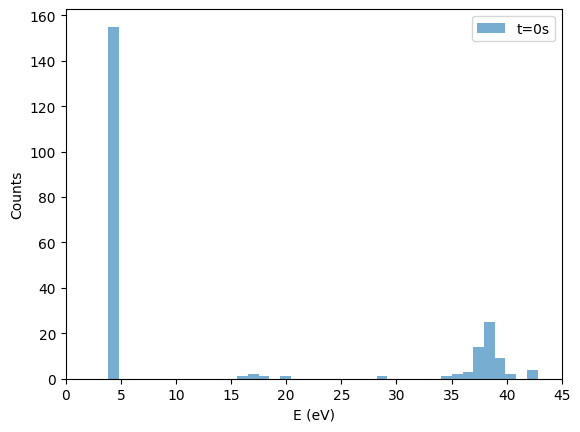

In [17]:
#histogramy fwhm piku Raman E
plt.hist(fwhms_Raman_E_0s, bins=40, label="t=0s", alpha=0.6)

plt.xlabel(r"E (eV)")
plt.ylabel("Counts")
plt.legend()
plt.xlim(0,45)
plt.savefig(sciezka/'histogram_fwhm_Raman_E.png')

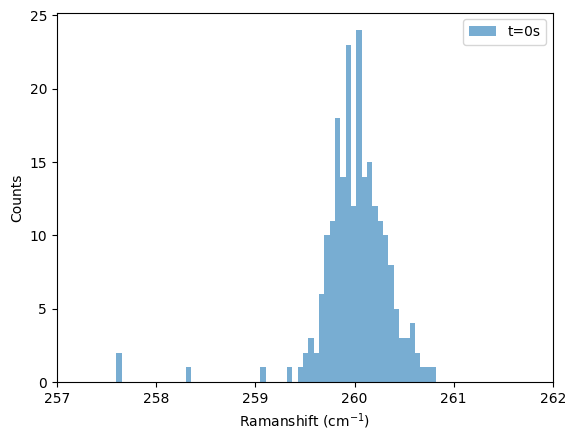

In [19]:
#histogramy pozycji piku Raman A
plt.hist(centers_Raman_A_0s, bins=60, label="t=0s", alpha=0.6)
plt.xlabel(r"Ramanshift (cm$^{-1}$)")
plt.ylabel("Counts")
plt.legend()
plt.xlim(257,262)
plt.savefig(sciezka/'histogram_pozycji_Raman_A.png')

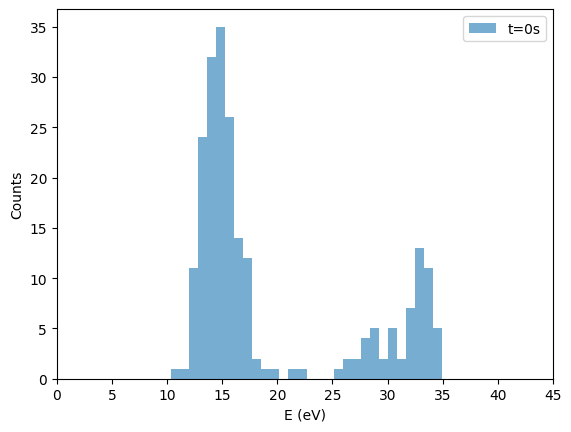

In [20]:
#histogramy fwhm piku Raman A
plt.hist(fwhms_Raman_A_0s, bins=30, label="t=0s", alpha=0.6)
plt.xlabel(r"E (eV)")
plt.ylabel("Counts")
plt.legend()
plt.xlim(0,45)
plt.savefig(sciezka/'histogram_fwhm_Raman_A.png')

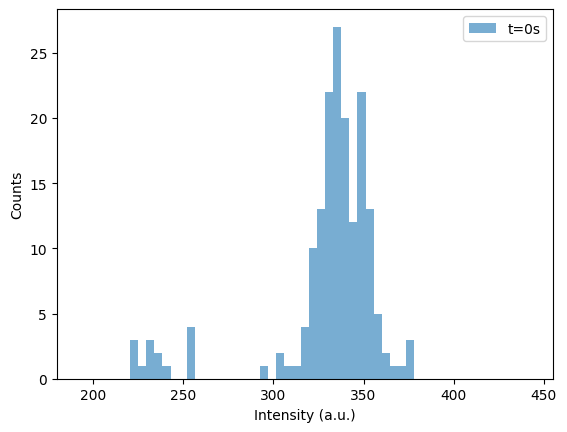

In [21]:
#histogramy intensywności Raman A

maska = (intensities_Raman_A_0s >= 220) & (intensities_Raman_A_0s <= 450)
intensities_Raman_A_0s = intensities_Raman_A_0s[maska]


plt.hist(intensities_Raman_A_0s, bins=35, label="t=0s", alpha=0.6)

plt.xlabel(r"Intensity (a.u.)")
plt.ylabel("Counts")
plt.legend()
plt.xlim(180,455)
plt.savefig(sciezka/'histogram_intensywnosci_Raman_A.png')

In [24]:
print(np.mean(intensities_PL_0s),np.mean(centers_PL_0s),np.mean(fwhms_PL_0s))

print(np.mean(intensities_Raman_E_0s),np.mean(centers_Raman_E_0s),np.mean(fwhms_Raman_E_0s))

print(np.mean(intensities_Raman_A_0s),np.mean(centers_Raman_A_0s),np.mean(fwhms_Raman_A_0s))

2840.3173021526954 1.6649965863463168 0.049238054555051376
2056.6321958265144 249.87172854324479 13.814462154378253
330.4235388482078 260.01093182686185 19.29591536509955
